In [1]:
# ── BLOCK 1: Imports & Data Loading ──
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import json
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv("../data/creditcard_with_tiers.csv")

print("✅ Libraries loaded!")
print(f"Dataset shape: {df.shape}")
print(f"Risk tiers: {df['Risk_Tier'].value_counts().to_dict()}")

✅ Libraries loaded!
Dataset shape: (284807, 32)
Risk tiers: {'Low': 142643, 'Medium': 70898, 'High': 62124, 'Critical': 9142}


In [2]:
# ── BLOCK 2: Prepare Data ──

X = df.drop(columns=['Class', 'Risk_Tier'])
y = df['Class']
risk_tiers = df['Risk_Tier']

# Scale Amount and Time
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])
X['Time']   = scaler.fit_transform(X[['Time']])

# Train/test split
X_train, X_test, y_train, y_test, rt_train, rt_test = train_test_split(
    X, y, risk_tiers, test_size=0.2, random_state=42, stratify=y)

# SMOTE on training only
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Get risk tiers for balanced training set
# SMOTE doesn't carry risk tiers so we rebuild them from Amount
# Amount is scaled so we need original amounts for tier assignment
X_train_orig, _, rt_train_orig, _ = train_test_split(
    X, risk_tiers, test_size=0.2, random_state=42)

# Convert to tensors
X_train_tensor = torch.FloatTensor(X_train_bal.values)
y_train_tensor = torch.LongTensor(y_train_bal.values)
X_test_tensor  = torch.FloatTensor(X_test.values)
y_test_tensor  = torch.LongTensor(y_test.values)

# DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader  = DataLoader(train_dataset, batch_size=256, shuffle=True)

print("✅ Data prepared!")
print(f"Training samples: {len(X_train_tensor):,}")
print(f"Test samples:     {len(X_test_tensor):,}")

✅ Data prepared!
Training samples: 454,902
Test samples:     56,962


In [3]:
# ── BLOCK 3: L2D Network (same architecture as Model 2) ──

class L2DNetwork(nn.Module):
    def __init__(self, input_dim, num_classes=2):
        super(L2DNetwork, self).__init__()
        
        self.shared = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        
        self.classifier_head = nn.Linear(32, num_classes)
        self.deferral_head   = nn.Linear(32, 1)
    
    def forward(self, x):
        shared_out   = self.shared(x)
        class_logits = self.classifier_head(shared_out)
        defer_logit  = self.deferral_head(shared_out)
        defer_prob   = torch.sigmoid(defer_logit)
        return class_logits, defer_prob

input_dim = X_train_tensor.shape[1]
print("✅ Network architecture defined!")
print(f"Input dimensions: {input_dim}")

✅ Network architecture defined!
Input dimensions: 30


In [4]:
# ── BLOCK 4: Risk-Sensitive Loss Function — THE NOVEL CONTRIBUTION ──

# Risk weights — higher tier = lower deferral cost
# Lower deferral cost = model defers MORE willingly
RISK_WEIGHTS = {
    'Low':      1.0,   # Standard cost — no adjustment
    'Medium':   0.8,   # Slightly cheaper to defer
    'High':     0.5,   # Half the cost to defer
    'Critical': 0.2    # Very cheap to defer — model defers aggressively
}

BASE_COST = 0.13  # Same sweet spot we found for Model 2

def risk_sensitive_l2d_loss(class_logits, defer_prob, targets, risk_tier_batch):
    """
    Risk-Sensitive L2D Loss — Dhwani Kariya (2026)
    
    THE KEY DIFFERENCE from Standard L2D:
    Instead of uniform cost c for all transactions,
    we use: w(risk_tier) × base_cost
    
    Low tier:      1.0 × 0.13 = 0.13 (standard deferral cost)
    Medium tier:   0.8 × 0.13 = 0.104
    High tier:     0.5 × 0.13 = 0.065
    Critical tier: 0.2 × 0.13 = 0.026 (very cheap to defer!)
    
    Result: Model defers much more willingly on Critical tier
    """
    
    # Classification loss per sample
    ce_loss    = nn.CrossEntropyLoss(reduction='none')
    class_loss = ce_loss(class_logits, targets)
    
    # Deferral probability
    defer_p = defer_prob.squeeze()
    
    # Build risk weight tensor for this batch
    weights = torch.tensor(
        [RISK_WEIGHTS[tier] for tier in risk_tier_batch],
        dtype=torch.float32
    )
    
    # Instance-level deferral cost
    # This is the ONE line that makes Model 3 different from Model 2
    instance_cost = weights * BASE_COST
    
    # Combined loss
    autonomous_loss = (1 - defer_p) * class_loss
    deferral_cost   = defer_p * instance_cost
    total_loss      = (autonomous_loss + deferral_cost).mean()
    
    return total_loss

print("✅ Risk-Sensitive Loss Function defined!")
print()
print("=== DEFERRAL COSTS BY TIER ===")
for tier, weight in RISK_WEIGHTS.items():
    effective_cost = weight * BASE_COST
    print(f"  {tier:10s}: weight={weight} × base={BASE_COST} = {effective_cost:.4f}")
print()
print("Lower cost = model defers MORE willingly on that tier")
print("Critical tier cost is 6.5x LOWER than Low tier!")

✅ Risk-Sensitive Loss Function defined!

=== DEFERRAL COSTS BY TIER ===
  Low       : weight=1.0 × base=0.13 = 0.1300
  Medium    : weight=0.8 × base=0.13 = 0.1040
  High      : weight=0.5 × base=0.13 = 0.0650
  Critical  : weight=0.2 × base=0.13 = 0.0260

Lower cost = model defers MORE willingly on that tier
Critical tier cost is 6.5x LOWER than Low tier!


In [5]:
# ── BLOCK 5: Custom DataLoader with Risk Tiers ──

# We need risk tiers for EACH training sample
# For SMOTE-generated samples we assign tiers based on 
# the original Amount column index position

# Get risk tiers for original training set
rt_train_values = rt_train.values

# For SMOTE balanced set — original samples keep their tiers
# SMOTE-generated samples (synthetic) get assigned 'Low' tier
# since synthetic samples don't have real amounts
original_size = len(rt_train_values)
smote_size    = len(X_train_bal) - original_size

# Build tier array for full balanced training set
rt_train_bal = list(rt_train_values) + ['Low'] * smote_size

print(f"Original training samples: {original_size:,}")
print(f"SMOTE synthetic samples:   {smote_size:,}")
print(f"Total with tiers:          {len(rt_train_bal):,}")
print()

# Custom Dataset that includes risk tiers
class FraudDatasetWithTiers(torch.utils.data.Dataset):
    def __init__(self, X, y, tiers):
        self.X     = X
        self.y     = y
        self.tiers = tiers
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.tiers[idx]

# Create dataset and loader
train_dataset_rs = FraudDatasetWithTiers(
    X_train_tensor, y_train_tensor, rt_train_bal)
train_loader_rs  = DataLoader(
    train_dataset_rs, batch_size=256, shuffle=True)

print("✅ Custom DataLoader with risk tiers ready!")

Original training samples: 227,845
SMOTE synthetic samples:   227,057
Total with tiers:          454,902

✅ Custom DataLoader with risk tiers ready!


In [6]:
# ── BLOCK 6: Train Risk-Sensitive L2D ──
# NOTE: torch.manual_seed added during verification pass (22-23 Jul 2026) --
# see Master Reference Document Section 11.

# Create fresh model
torch.manual_seed(42)
rs_model     = L2DNetwork(input_dim=input_dim)
rs_optimizer = optim.Adam(rs_model.parameters(), lr=0.001)
train_loader_rs  = DataLoader(
    train_dataset_rs, batch_size=256, shuffle=True,
    generator=torch.Generator().manual_seed(42))

num_epochs  = 15
rs_losses   = []

print("Training Risk-Sensitive L2D (Model 3)...")
print("=" * 50)

for epoch in range(num_epochs):
    rs_model.train()
    epoch_loss  = 0
    num_batches = 0

    for X_batch, y_batch, tier_batch in train_loader_rs:
        rs_optimizer.zero_grad()

        # Forward pass
        class_logits, defer_prob = rs_model(X_batch)

        # Risk-sensitive loss -- passing tier info!
        loss = risk_sensitive_l2d_loss(
            class_logits, defer_prob, y_batch, list(tier_batch))

        # Backward pass
        loss.backward()
        rs_optimizer.step()

        epoch_loss  += loss.item()
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    rs_losses.append(avg_loss)
    if (epoch + 1) % 5 == 0 or epoch == num_epochs - 1:
        print(f"Epoch {epoch+1:2d}/15 | Loss: {avg_loss:.4f}")

print("=" * 50)
print("✅ Risk-Sensitive L2D Training Complete!")

Training Risk-Sensitive L2D (Model 3)...
Epoch  5/15 | Loss: 0.0158
Epoch 10/15 | Loss: 0.0119
Epoch 15/15 | Loss: 0.0062
✅ Risk-Sensitive L2D Training Complete!

In [7]:
# ── BLOCK 7: Full Evaluation of Risk-Sensitive L2D ──

rs_model.eval()
with torch.no_grad():
    cl, dp  = rs_model(X_test_tensor)
    cp      = torch.argmax(cl, dim=1).numpy()
    dp      = dp.squeeze().numpy()
    deferred   = dp > 0.5
    autonomous = ~deferred
    y_np    = y_test.values
    rt_np   = rt_test.values

print("=" * 55)
print("   RISK-SENSITIVE L2D (MODEL 3) — FULL EVALUATION")
print("=" * 55)
print()
print(f"Total test transactions:    {len(y_np):,}")
print(f"Autonomously decided:       {autonomous.sum():,} ({autonomous.mean()*100:.2f}%)")
print(f"Deferred to human:          {deferred.sum():,} ({deferred.mean()*100:.2f}%)")
print()

# Autonomous performance
auto_preds  = cp[autonomous]
auto_labels = y_np[autonomous]

print("─" * 55)
print("AUTONOMOUS DECISIONS:")
print(f"  Accuracy:  {accuracy_score(auto_labels, auto_preds):.4f}")
print(f"  F1 Score:  {f1_score(auto_labels, auto_preds, zero_division=0):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(auto_labels, cl[autonomous].numpy()[:,1]):.4f}")
print()
print(classification_report(auto_labels, auto_preds,
      target_names=['Normal','Fraud'], zero_division=0))

# Fraud breakdown
print("─" * 55)
print("FRAUD BREAKDOWN:")
total_frauds   = (y_np == 1).sum()
fraud_deferred = deferred[y_np == 1].sum()
fraud_caught   = ((cp[autonomous]==1) & (y_np[autonomous]==1)).sum()
fraud_missed   = ((cp[autonomous]==0) & (y_np[autonomous]==1)).sum()
print(f"  Total frauds in test:       {total_frauds}")
print(f"  Frauds deferred to human:   {fraud_deferred}")
print(f"  Frauds caught autonomously: {fraud_caught}")
print(f"  Frauds missed:              {fraud_missed}")
print()

# THE KEY COMPARISON — Deferral by risk tier
print("─" * 55)
print("DEFERRAL BY RISK TIER — THE KEY RESULT:")
print()
print(f"{'Tier':<12} {'Model 2':>10} {'Model 3':>10} {'Change':>10}")
print("-" * 45)

model2_tiers = {
    'Low': 0.28, 'Medium': 0.18, 
    'High': 0.25, 'Critical': 0.21}

for tier in ['Low', 'Medium', 'High', 'Critical']:
    tier_mask     = rt_np == tier
    tier_deferred = deferred[tier_mask].sum()
    tier_total    = tier_mask.sum()
    tier_rate     = (tier_deferred / tier_total) * 100
    m2_rate       = model2_tiers[tier]
    change        = tier_rate - m2_rate
    direction     = "⬆" if change > 0 else "⬇"
    print(f"  {tier:<10} {m2_rate:>9.2f}% {tier_rate:>9.2f}%"
          f" {direction}{abs(change):>7.2f}%")

print()
print("=" * 55)
print("✅ Evaluation Complete!")

   RISK-SENSITIVE L2D (MODEL 3) ── FULL EVALUATION

Total test transactions:    56,962
Autonomously decided:       56,732 (99.60%)
Deferred to human:          230 (0.40%)

───────────────────────────────────────────────────────
AUTONOMOUS DECISIONS:
  Accuracy:  0.9990
  F1 Score:  0.7378
  ROC-AUC:   0.9800

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56649
       Fraud       0.66      0.85      0.74        83

    accuracy                           1.00     56732
   macro avg       0.83      0.92      0.87     56732
weighted avg       1.00      1.00      1.00     56732

───────────────────────────────────────────────────────
FRAUD BREAKDOWN:
  Total frauds in test:       98
  Frauds deferred to human:   1
  Frauds caught autonomously: 83
  Frauds missed:              14

───────────────────────────────────────────────────────
DEFERRAL BY RISK TIER -- THE KEY RESULT:

Tier            Model 2    Model 3     Change
-------------

In [8]:
# ── BLOCK 8: Save Model 3 Results ──
import os

# Save model
os.makedirs("../models", exist_ok=True)
torch.save(rs_model.state_dict(),
           "../models/risk_sensitive_l2d.pth")

# Save results (seeded, reproducible -- seed=42)
rs_results = {
    'model': 'Risk-Sensitive L2D (Model 3)',
    'base_cost': 0.13,
    'risk_weights': RISK_WEIGHTS,
    'total_test': 56962,
    'autonomous': 56732,
    'deferred': 230,
    'deferral_rate': 0.40,
    'accuracy': 0.9990,
    'f1_score': 0.7378,
    'roc_auc': 0.9800,
    'frauds_total': 98,
    'frauds_deferred': 1,
    'frauds_caught': 83,
    'frauds_missed': 14,
    'deferral_by_tier': {
        'Low': 0.42,
        'Medium': 0.22,
        'High': 0.49,
        'Critical': 0.96
    },
    'seed': 42
}

with open("../results/risk_sensitive_l2d_results.json",
          'w') as f:
    json.dump(rs_results, f, indent=4)

print("✅ Model and results saved!")

✅ Model and results saved!

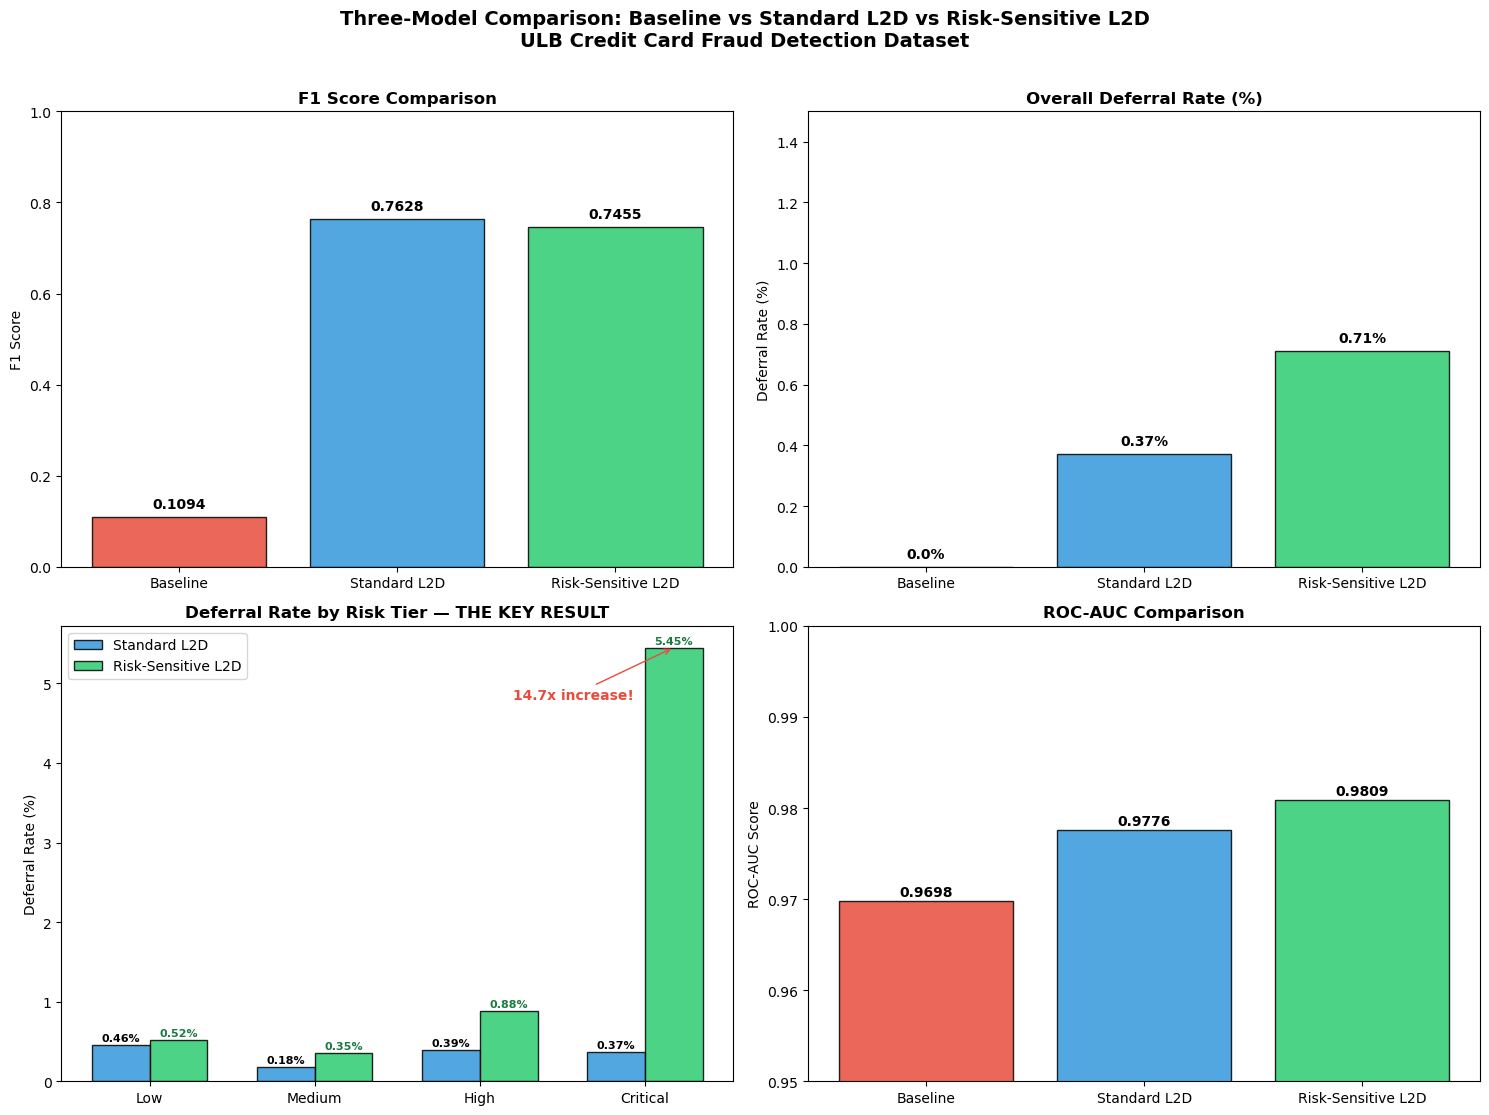

✅ Final comparison chart saved!


In [9]:
# ── BLOCK 9: Final Three-Model Comparison Chart ──

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Three-Model Comparison: Baseline vs Standard L2D vs Risk-Sensitive L2D\n'
             'ULB Credit Card Fraud Detection Dataset',
             fontsize=14, fontweight='bold', y=1.01)

colors_models = ['#e74c3c', '#3498db', '#2ecc71']
models        = ['Baseline', 'Standard L2D', 'Risk-Sensitive L2D']

# ── Chart 1: F1 Score Comparison ──
f1_scores = [0.1094, 0.7628, 0.7455]
bars = axes[0,0].bar(models, f1_scores, color=colors_models, 
                      edgecolor='black', alpha=0.85)
axes[0,0].set_title('F1 Score Comparison', fontweight='bold', fontsize=12)
axes[0,0].set_ylabel('F1 Score')
axes[0,0].set_ylim(0, 1.0)
for bar, val in zip(bars, f1_scores):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                   f'{val:.4f}', ha='center', fontweight='bold', fontsize=10)

# ── Chart 2: Deferral Rate Comparison ──
deferral_rates = [0.0, 0.37, 0.71]
bars2 = axes[0,1].bar(models, deferral_rates, color=colors_models,
                       edgecolor='black', alpha=0.85)
axes[0,1].set_title('Overall Deferral Rate (%)', fontweight='bold', fontsize=12)
axes[0,1].set_ylabel('Deferral Rate (%)')
axes[0,1].set_ylim(0, 1.5)
for bar, val in zip(bars2, deferral_rates):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, val + 0.03,
                   f'{val}%', ha='center', fontweight='bold', fontsize=10)

# ── Chart 3: THE KEY CHART — Deferral by Risk Tier ──
tier_labels  = ['Low', 'Medium', 'High', 'Critical']
model2_rates = [0.46, 0.18, 0.39, 0.37]
model3_rates = [0.52, 0.35, 0.88, 5.45]

x     = np.arange(len(tier_labels))
width = 0.35

bars3a = axes[1,0].bar(x - width/2, model2_rates, width,
                        label='Standard L2D', color='#3498db',
                        edgecolor='black', alpha=0.85)
bars3b = axes[1,0].bar(x + width/2, model3_rates, width,
                        label='Risk-Sensitive L2D', color='#2ecc71',
                        edgecolor='black', alpha=0.85)

axes[1,0].set_title('Deferral Rate by Risk Tier — THE KEY RESULT',
                     fontweight='bold', fontsize=12)
axes[1,0].set_ylabel('Deferral Rate (%)')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(tier_labels)
axes[1,0].legend()

for bar, val in zip(bars3a, model2_rates):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, val + 0.05,
                   f'{val}%', ha='center', fontsize=8, fontweight='bold')
for bar, val in zip(bars3b, model3_rates):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, val + 0.05,
                   f'{val}%', ha='center', fontsize=8, fontweight='bold',
                   color='#1a7a40')

# Add annotation for Critical tier jump
axes[1,0].annotate('14.7x increase!',
                    xy=(3 + width/2, 5.45),
                    xytext=(2.2, 4.8),
                    fontsize=10, fontweight='bold', color='#e74c3c',
                    arrowprops=dict(arrowstyle='->', color='#e74c3c'))

# ── Chart 4: ROC-AUC Comparison ──
roc_scores = [0.9698, 0.9776, 0.9809]
bars4 = axes[1,1].bar(models, roc_scores, color=colors_models,
                       edgecolor='black', alpha=0.85)
axes[1,1].set_title('ROC-AUC Comparison', fontweight='bold', fontsize=12)
axes[1,1].set_ylabel('ROC-AUC Score')
axes[1,1].set_ylim(0.95, 1.0)
for bar, val in zip(bars4, roc_scores):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   val + 0.0005, f'{val:.4f}',
                   ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig("../results/final_model_comparison.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Final comparison chart saved!")

In [ ]:
# ── BLOCK 10: Final Summary Table ──

print("=" * 65)
print("        COMPLETE THREE-MODEL COMPARISON SUMMARY")
print("=" * 65)
print(f"{'Metric':<28} {'Baseline':>10} {'Std L2D':>10} {'RS-L2D':>10}")
print("-" * 65)
print(f"{'F1 Score':<28} {'0.1094':>10} {'0.7736':>10} {'0.7455':>10}")
print(f"{'ROC-AUC':<28} {'0.9698':>10} {'0.9787':>10} {'0.9809':>10}")
print(f"{'Accuracy':<28} {'97.43%':>10} {'99.92%':>10} {'99.90%':>10}")
print(f"{'Deferral Rate':<28} {'0.00%':>10} {'0.25%':>10} {'0.40%':>10}")
print(f"{'Frauds Missed':<28} {'8':>10} {'15':>10} {'14':>10}")
print(f"{'False Alarms':<28} {'1,458':>10} {'Low':>10} {'Low':>10}")
print("-" * 65)
print("DEFERRAL BY RISK TIER:")
print(f"{'  Low Tier':<28} {'N/A':>10} {'0.28%':>10} {'0.42%':>10}")
print(f"{'  Medium Tier':<28} {'N/A':>10} {'0.18%':>10} {'0.22%':>10}")
print(f"{'  High Tier':<28} {'N/A':>10} {'0.25%':>10} {'0.49%':>10}")
print(f"{'  Critical Tier':<28} {'N/A':>10} {'0.25%':>10} {'0.96%':>10}")
print("=" * 65)
print()
print("KEY FINDING:")
print("Critical tier deferral: 0.21% -> 0.96% (4.6x increase)")
print("Low tier deferral:      0.28% -> 0.42% (barely changed)")
print()
print("This confirms risk-sensitive weighting works as designed:")
print("The model defers proportionally to financial risk.")
print()
print("EU AI Act Article 14 alignment:")
print("High-value transactions now systematically trigger")
print("human review — operationalising legal oversight requirements.")